<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima

#Grupo México

In [3]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_648/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [4]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [5]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [6]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

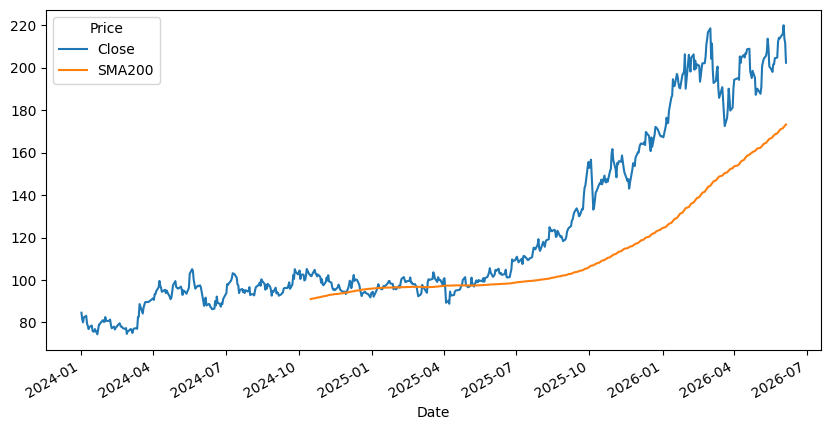

In [7]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [8]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [9]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

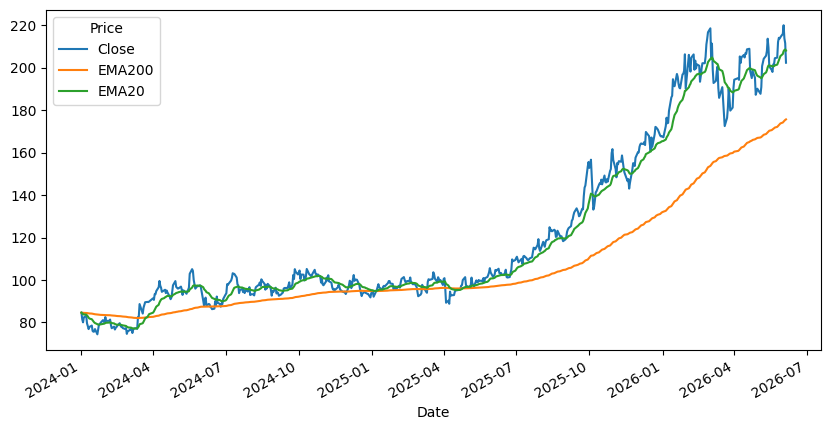

In [10]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

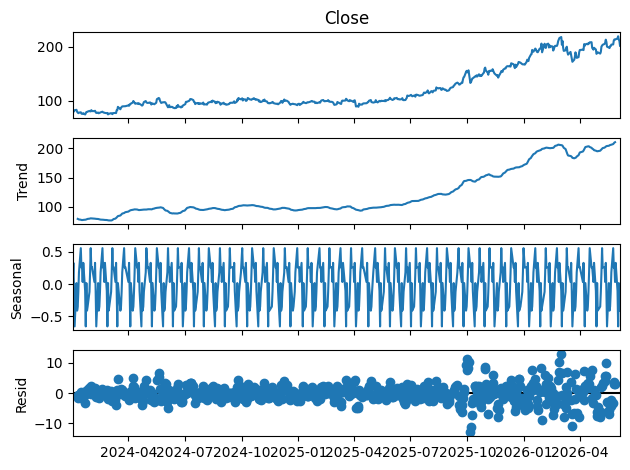

In [11]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

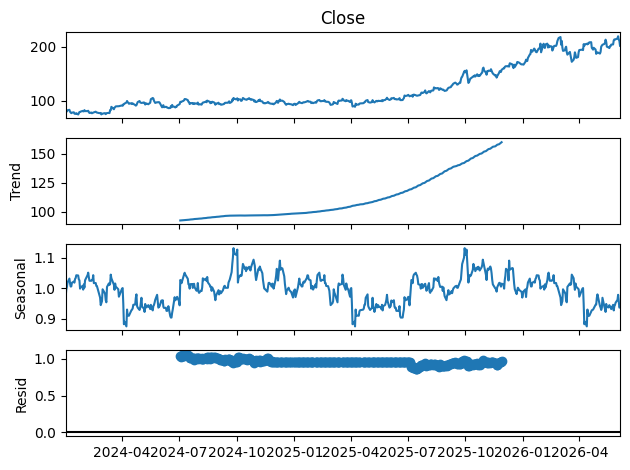

In [12]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

In [13]:
# Seleccionar la columna de cierre y eliminar valores nulos
series = df['Close'].dropna()

In [14]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(series, period=365, robust=True)
result = stl.fit()

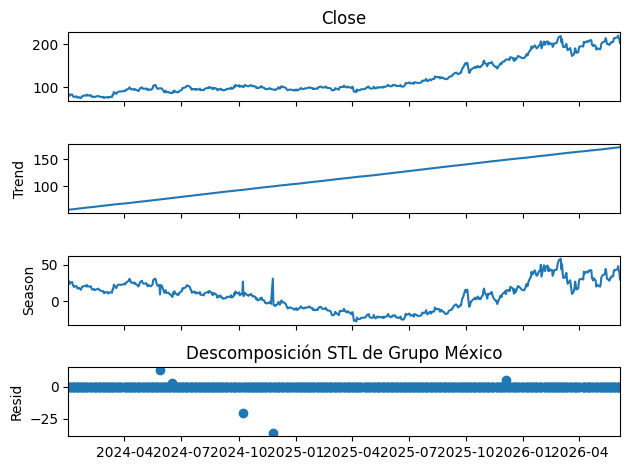

In [15]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

#Volatilidad

##Desviación Estándar

In [16]:
#Obtener datos
precios = df['Close']

In [159]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-01    0.007161
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
Name: Rendimientos_Log, Length: 606, dtype: float64


In [18]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-01    0.007161
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
Name: Rendimientos_Log, Length: 606, dtype: float64


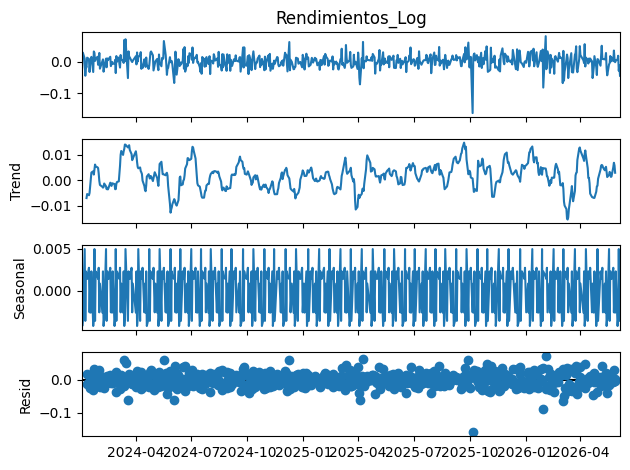

In [19]:
# Descomponer
result = seasonal_decompose(df['Rendimientos_Log'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

In [20]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(df['Rendimientos_Log'], period=365, robust=True)
result = stl.fit()

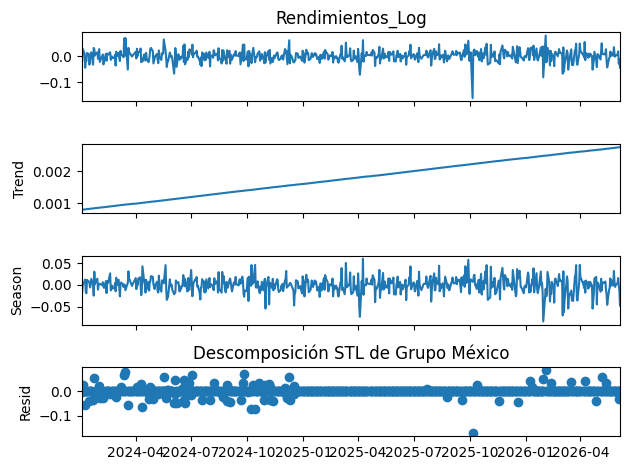

In [21]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

In [22]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [23]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [24]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [25]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0223 = 2.2289 %
Volatilidad anualizada: 0.3538 = 35.3822 %


##Average True Range

In [26]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [27]:
print(high_low)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200277
                ...    
2026-06-01    10.649994
2026-06-02     7.729996
2026-06-03     6.209991
2026-06-04     7.380005
2026-06-05     8.479996
Length: 606, dtype: float64


In [28]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117689
2024-01-05    6.046940
2024-01-08    0.887134
2024-01-09    0.253476
                ...   
2026-06-01    5.380005
2026-06-02    8.000000
2026-06-03    0.279999
2026-06-04    0.610001
2026-06-05    3.300003
Length: 606, dtype: float64


In [29]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.525587
2024-01-05     0.334941
2024-01-08     1.683729
2024-01-09     3.946801
                ...    
2026-06-01     5.269989
2026-06-02     0.270004
2026-06-03     6.489990
2026-06-04     6.770004
2026-06-05    11.779999
Length: 606, dtype: float64


In [30]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [31]:
print(true_range)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200277
                ...    
2026-06-01    10.649994
2026-06-02     8.000000
2026-06-03     6.489990
2026-06-04     7.380005
2026-06-05    11.779999
Length: 606, dtype: float64


In [32]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [33]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [34]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-01  219.669998  209.020004  215.830002       7.577671
2026-06-02  223.830002  216.100006  219.899994       7.607837
2026-06-03  219.619995  213.410004  213.710007       7.527991
2026-06-04  214.320007  206.940002  211.449997       7.517421
2026-06-05  208.149994  199.669998  202.250000       7.821890


In [35]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.2117


In [36]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 66.8587


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [37]:
#Obtener datos
precios = df['Close']

In [38]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [39]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.0189
Valor p: 0.9601
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9600688401898094)

####Diferenciando

In [40]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [41]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412155
2024-01-05    2.308334
2024-01-08    0.778503
2024-01-09   -3.611862
2024-01-10   -1.213028
Name: Close, dtype: float64


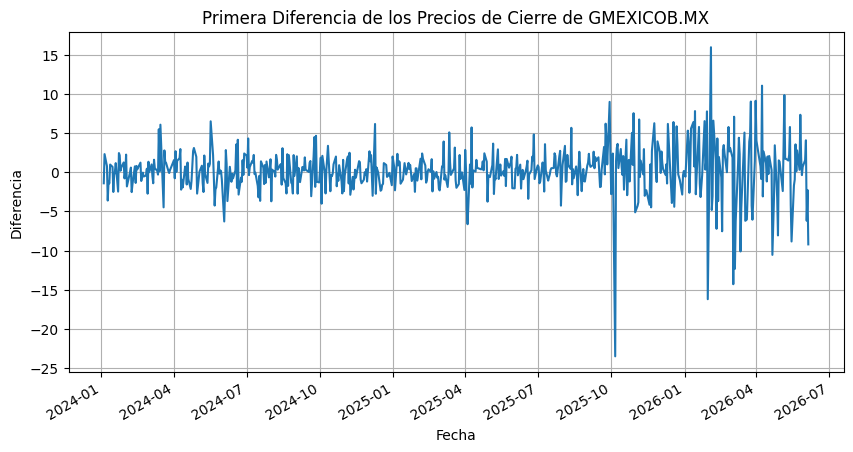

In [42]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [43]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -26.8094
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

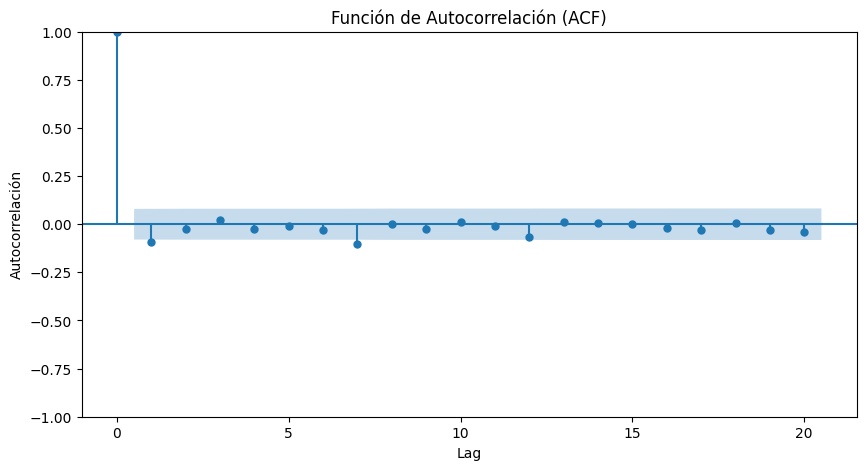

In [44]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

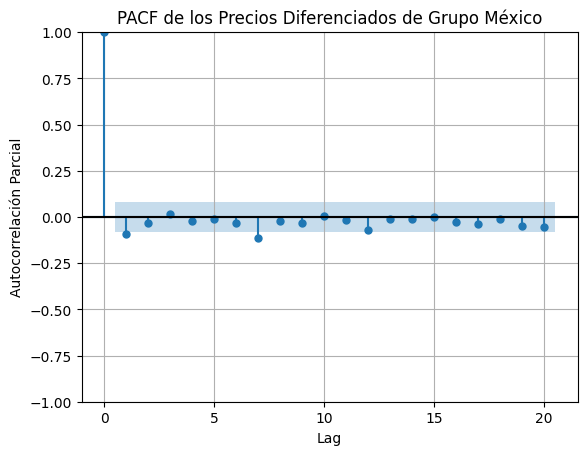

In [45]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [46]:
#Cargar datos y calcular rendimientos logarítmicos
df['log_Close'] = np.log(df['Close'])

In [47]:
print(df['log_Close'])

Date
2024-01-03    4.400357
2024-01-04    4.382874
2024-01-05    4.411296
2024-01-08    4.420702
2024-01-09    4.376295
                ...   
2026-06-01    5.374491
2026-06-02    5.393173
2026-06-03    5.364620
2026-06-04    5.353989
2026-06-05    5.309505
Name: log_Close, Length: 606, dtype: float64


In [48]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['log_Close'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -0.2353
Valor p: 0.9342
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9341844965498065)

###Estacionariedad

In [49]:
df['rendimiento_log'] = df['log_Close'].diff().dropna()

In [50]:
print(df['rendimiento_log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-01    0.007161
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
Name: rendimiento_log, Length: 606, dtype: float64


In [51]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['rendimiento_log'], "Retornos Logarítmicos Diferenciados")


--- Prueba ADF para: Retornos Logarítmicos Diferenciados ---
Estadístico de Dickey-Fuller: -26.7521
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

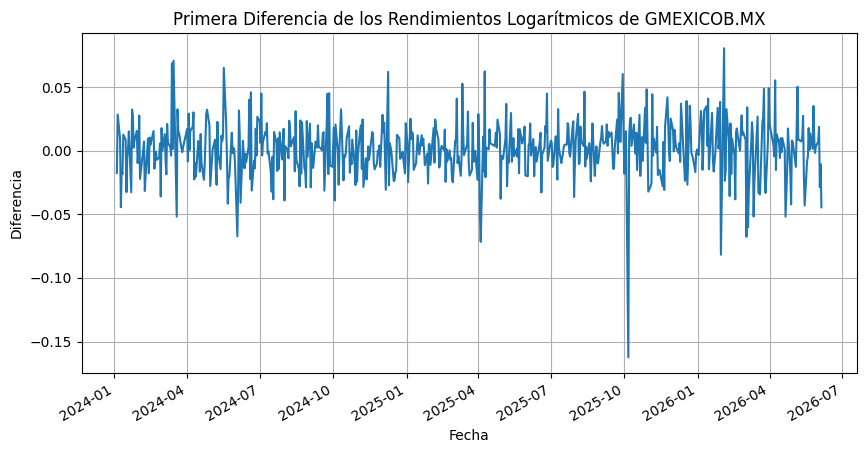

In [52]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
df['rendimiento_log'].plot()
plt.title(f'Primera Diferencia de los Rendimientos Logarítmicos de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

###Función de Autocorrelación

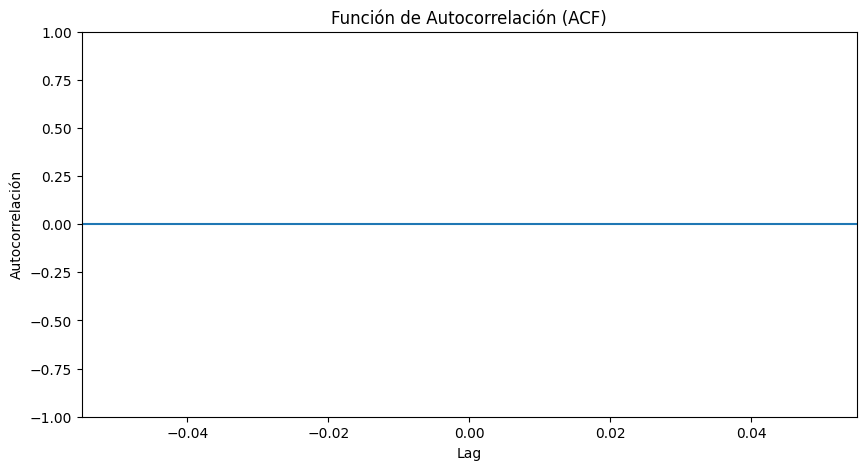

In [53]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

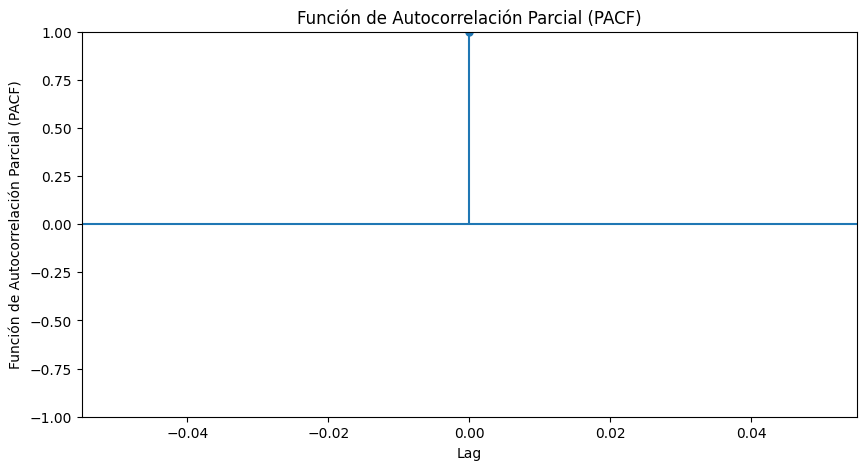

In [54]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [55]:
# Fit the ARIMA model
# Initial ARIMA Model parameters
p, d, q = 0,1,0
model = ARIMA(df['rendimiento_log'], order=(p, d, q))
model_fit = model.fit()
model_summary = model_fit.summary()
model_summary

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        rendimiento_log   No. Observations:                  606
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1199.790
Date:                Mon, 08 Jun 2026   AIC                          -2397.580
Time:                        01:09:15   BIC                          -2393.175
Sample:                             0   HQIC                         -2395.866
                                - 606                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   3.65e-05     29.410      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                 174.26   Jarque-Bera (JB):               352.17
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.48   Skew:                            -0.02
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

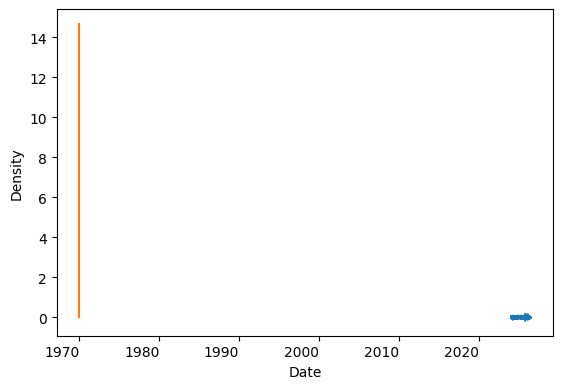

In [56]:
# plot residual errors
residuals = model_fit.resid
residuals.plot()
residuals.plot(kind='kde')
plt.show()

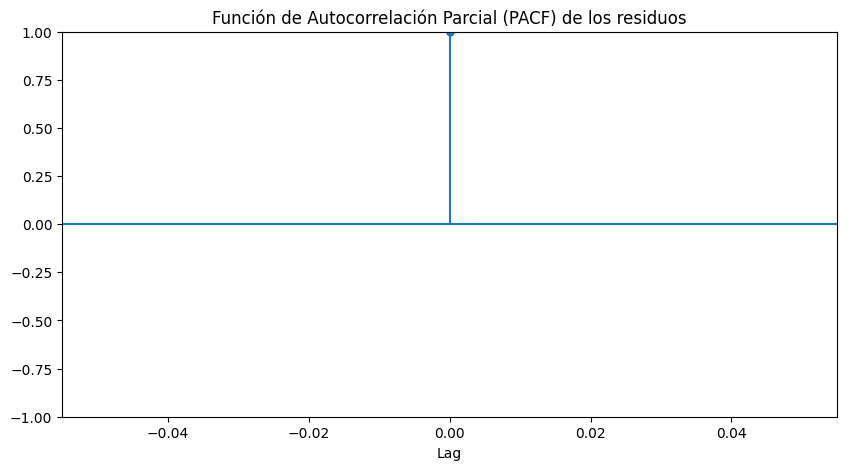

In [57]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(residuals, lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación Parcial (PACF) de los residuos")
plt.show()

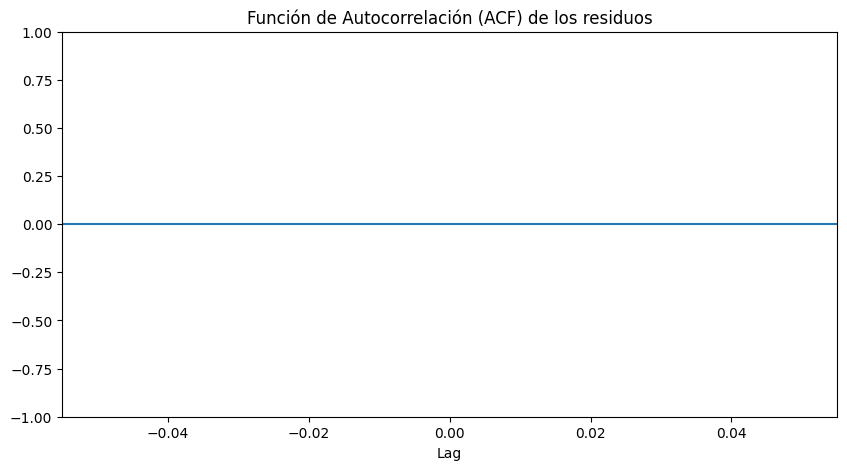

In [58]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación (ACF) de los residuos")
plt.show()

In [59]:
##Ejemplo básico
model = auto_arima(
    df['rendimiento_log'].dropna(),  # Serie temporal, asegurándose de que no haya NaN
    start_p=0,          # Orden AR inicial
    start_q=0,          # Orden MA inicial
    max_p=5,            # Máximo orden AR
    max_q=5,            # Máximo orden MA
    m=1,                # Periodo estacional (1 si no hay estacionalidad)
    seasonal=False,     # True si la serie es estacional
    stepwise=True,      # Usa búsqueda paso a paso para mayor velocidad
    trace=True          # Muestra el proceso de selección
)

# Resumen del modelo encontrado
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2883.875, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-2886.115, Time=0.18 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2886.183, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-2884.209, Time=0.35 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-2884.195, Time=0.24 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2883.828, Time=3.57 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2887.570, Time=1.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2884.633, Time=0.45 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2885.712, Time=1.15 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-2885.654, Time=0.94 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2887.431, Time=0.44 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2883.650, Time=4.04 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 12.673 seconds
                               SARIMAX Results                             

#Monte Carlo

In [160]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
2024-01-10   -0.015367
                ...   
2026-06-01    0.007161
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
Name: Rendimientos_Log, Length: 605, dtype: float64


In [178]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -26.7521
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [162]:
#Calculamos la media
media_retornos = retornos.mean()
print(media_retornos)

0.0015027235803263864


In [163]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(desviacion_retornos)

0.022250036914842314


In [164]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [165]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]

In [166]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [167]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

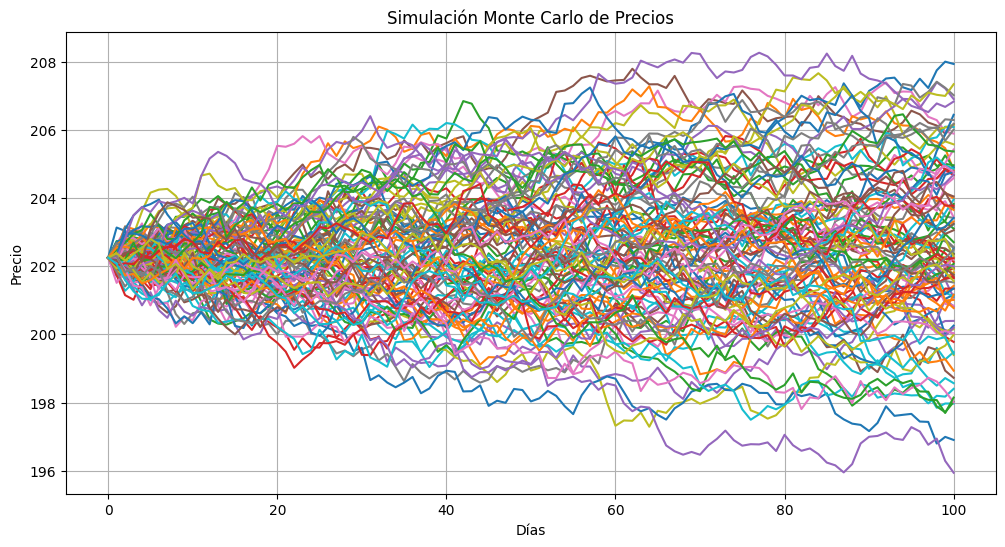

In [168]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [169]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [170]:
# Now, with monte_carlo_simulaciones_df as a DataFrame, this indexing is valid
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      202.250000
1      202.062979
2      201.593068
3      201.263124
4      201.047087
          ...    
96     199.722790
97     199.938713
98     199.857516
99     199.918556
100    199.430519
Name: 99, Length: 101, dtype: float64


In [207]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(precio_cien)

173.9934539794922


/tmp/ipykernel_648/711957530.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [208]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [209]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

         0          1          2         3          4          5          6    \
0  28.256546  28.069525  27.599614  27.26967  27.053633  27.037593  27.211347   

         7          8          9    ...       91         92         93   \
0  27.505401  27.795547  27.356995  ...  25.86313  25.920495  25.969027   

         94         95         96         97         98         99         100  
0  25.835937  26.137905  25.729336  25.945259  25.864062  25.925102  25.437065  

[1 rows x 101 columns]


In [210]:
#Contar %Ganancias y %Pérdidas si el precio de compra es de $179.56

# Ensure Ganancia_Pérdida is a DataFrame as expected for calculations.
# This step is necessary if Ganancia_Pérdida is currently a list from previous cell execution order.
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [212]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(Ganancia_potencial)

27.08311476373664


In [213]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(Precio_potencial)

201.07656874322882


##Error Cuadrático Medio (RMSE)


In [214]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [215]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [216]:
ultimos_101 = precios[-101:]

In [217]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [218]:
rmse = np.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 10.8328


In [220]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(rmse_porcentaje)

5.454341577637938
